# ECON 3916: ML Prediction Project — Final Project

**From Question to Recommendation**

This notebook scaffolds your final project. Work through each part sequentially. By Week 12, this notebook (plus your `app.py` and report) will form your complete submission.

**AI Policy:** AI co-pilot is REQUIRED. Document every AI interaction in Part 7 (AI Methodology Appendix) using the P.R.I.M.E. framework.

---

## Part 0: Setup

In [1]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement

Fill in each blank below. This becomes the opening paragraph of your report.

**My prediction question is:** Given a home's attributes, location, and condition what is its expected sale price? 

**This is a prediction (umbrella) problem because:** ___
This is a prediction as the investigation's goal is to forecat sale price (Y) from home's features (X) rather than identifying the causal effect of any feature. If a feature is predictive of a price does not autoatically make it a feature that if changed would influence the sale price. 

**The decision this enables:** ___
A real estate brokerage can use the model to recommend an evidence-based listing price to sellers. The model will give an uncertainty range as well as flagging listings whose asking price is outside the expected raange. 

**Dataset:** Ames Housing Dataset 
- **Source:** De Cock, D. (2011). Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester Regression Project. Journal of Statistics Education, 19(3). Distributed via OpenML. (URL:(https://www.openml.org/d/42165))
- **N =** 1460 home sales
- **Features =** 79 explanatory variables
- **Target variable =** SalePrice
- **Access date:** April 16, 2026

---
## Part 2: Data Loading + EDA

### 2.1 Load Your Data

In [3]:
# ============================================================
# 2.1 Load your dataset
# ============================================================

df = pd.read_csv('data/ames_housing.csv')


print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (1460, 81)
Columns: ['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenP

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### 2.2 Basic Description

In [4]:
# ============================================================
# 2.2 Describe your data
# ============================================================

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### 2.3 Missing Data Assessment

Missing data (%) by column:
PoolQC          0.995205
MiscFeature     0.963014
Alley           0.937671
Fence           0.807534
MasVnrType      0.597260
FireplaceQu     0.472603
LotFrontage     0.177397
GarageYrBlt     0.055479
GarageCond      0.055479
GarageType      0.055479
GarageFinish    0.055479
GarageQual      0.055479
BsmtFinType2    0.026027
BsmtExposure    0.026027
BsmtQual        0.025342
BsmtCond        0.025342
BsmtFinType1    0.025342
MasVnrArea      0.005479
Electrical      0.000685
dtype: float64


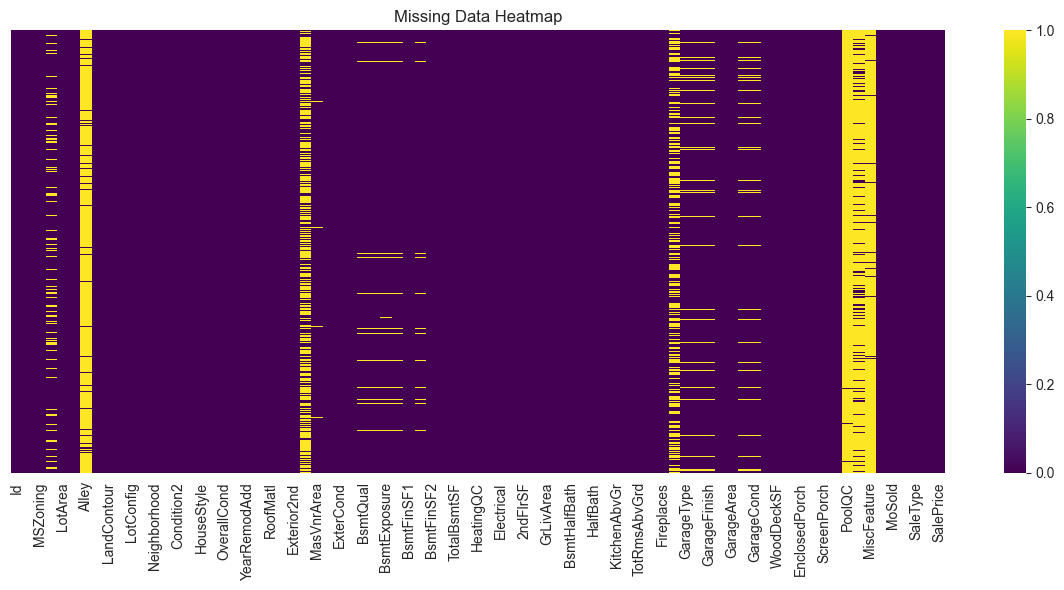

In [5]:
# ============================================================
# 2.3 Missing data heatmap (Ch 1: MCAR/MAR/MNAR)
# ============================================================

missing_pct = df.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct[missing_pct > 0])

# # Visual: missing data heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

**Missing data strategy:** ___ 
(Is this MCAR, MAR, or MNAR? What will you do — drop, impute, or flag?)
Mainly MNAR, columns such as PoolQc(99.5%) and MiscFeature(96.3%) are missing as the home lacks the feature. For these types of columns I will impute with "None" to represent the absence. For related numeric columns I will impute with 0. LotFrontage (17.7% missing) is likely MAR, as the absence may depend on the neighborhood so I will impute with the median LotFrontage by neighborhood. Electrical is 0.07% I will impute it with the mode wince its a single random occurrence, MCAR. 

### 2.4 Distribution Plots

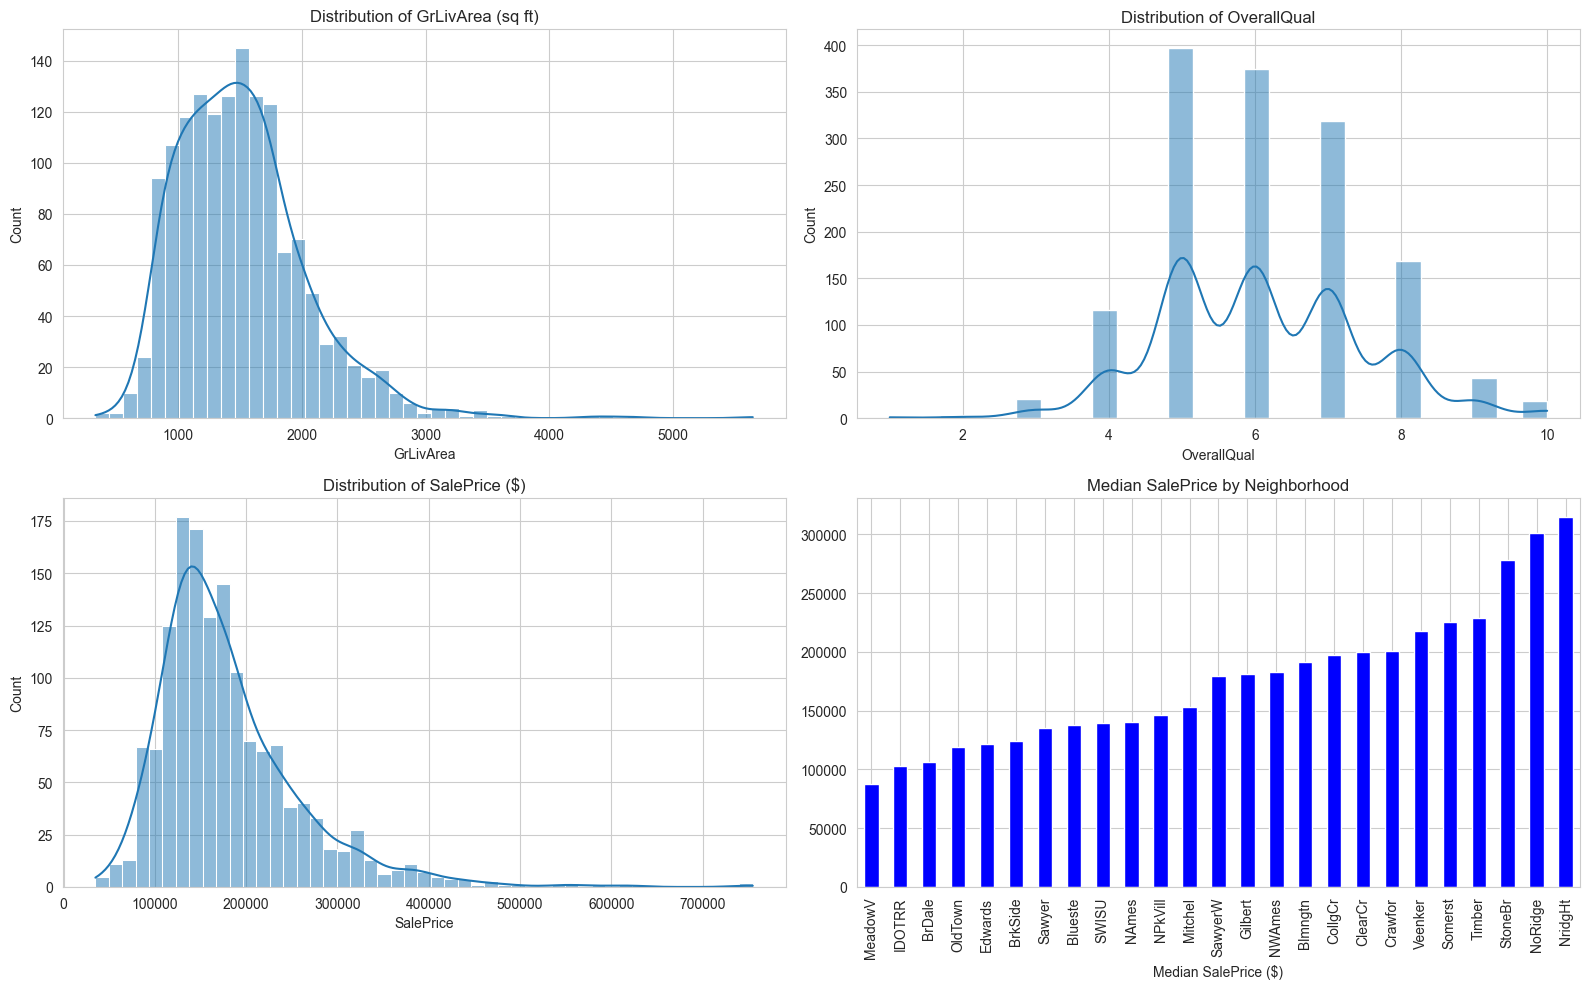

In [10]:
# ============================================================
# 2.4 Distribution of key features (Ch 3)
# ============================================================

# # Plot distributions for your most important features
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(df['GrLivArea'], kde=True, ax=axes[0,0])
axes[0,0].set_title('Distribution of GrLivArea (sq ft)')
# 
sns.histplot(df['OverallQual'], kde=True, ax=axes[0,1])
axes[0,1].set_title('Distribution of OverallQual')
# 
sns.histplot(df['SalePrice'], kde=True, ax=axes[1,0])
axes[1,0].set_title('Distribution of SalePrice ($)')
# Neighborhood is categorical so I will use the median SalePrice by Neighborhood instead of a histogram
neighborhood_median = df.groupby('Neighborhood')['SalePrice'].median().sort_values()
neighborhood_median.plot(kind='bar', ax=axes[1,1], color='blue')
axes[1,1].set_title('Median SalePrice by Neighborhood')
axes[1,1].set_xlabel('Median SalePrice ($)')

plt.tight_layout()
plt.show()

### 2.5 Outlier Detection

In [11]:
# ============================================================
# 2.5 Outlier detection (Ch 4: Tukey Fences / IQR)
# ============================================================

def tukey_fences(series, k=1.5):
    """Return lower and upper Tukey fences."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR

#check outliers in a numeric column
for col in ['GrLivArea', 'OverallQual', 'SalePrice']:
    lower, upper = tukey_fences(df[col])
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)')

GrLivArea: 31 outliers (2.1%)
OverallQual: 2 outliers (0.1%)
SalePrice: 61 outliers (4.2%)


**Outlier strategy:** ___
(Trim? Winsorize? Keep with justification?)
The outliers should be kept. Saleprice has the highest amount of outliers, which should be kept as it reflects data for large or expensive homes. OverallQual has a very small amount of outliers which can be ignored (0.1%). Trimming the outliers would remove high-end sales and make the model biased towards mid-range homes. I will use models that are robust to outliers

### 2.6 Correlations

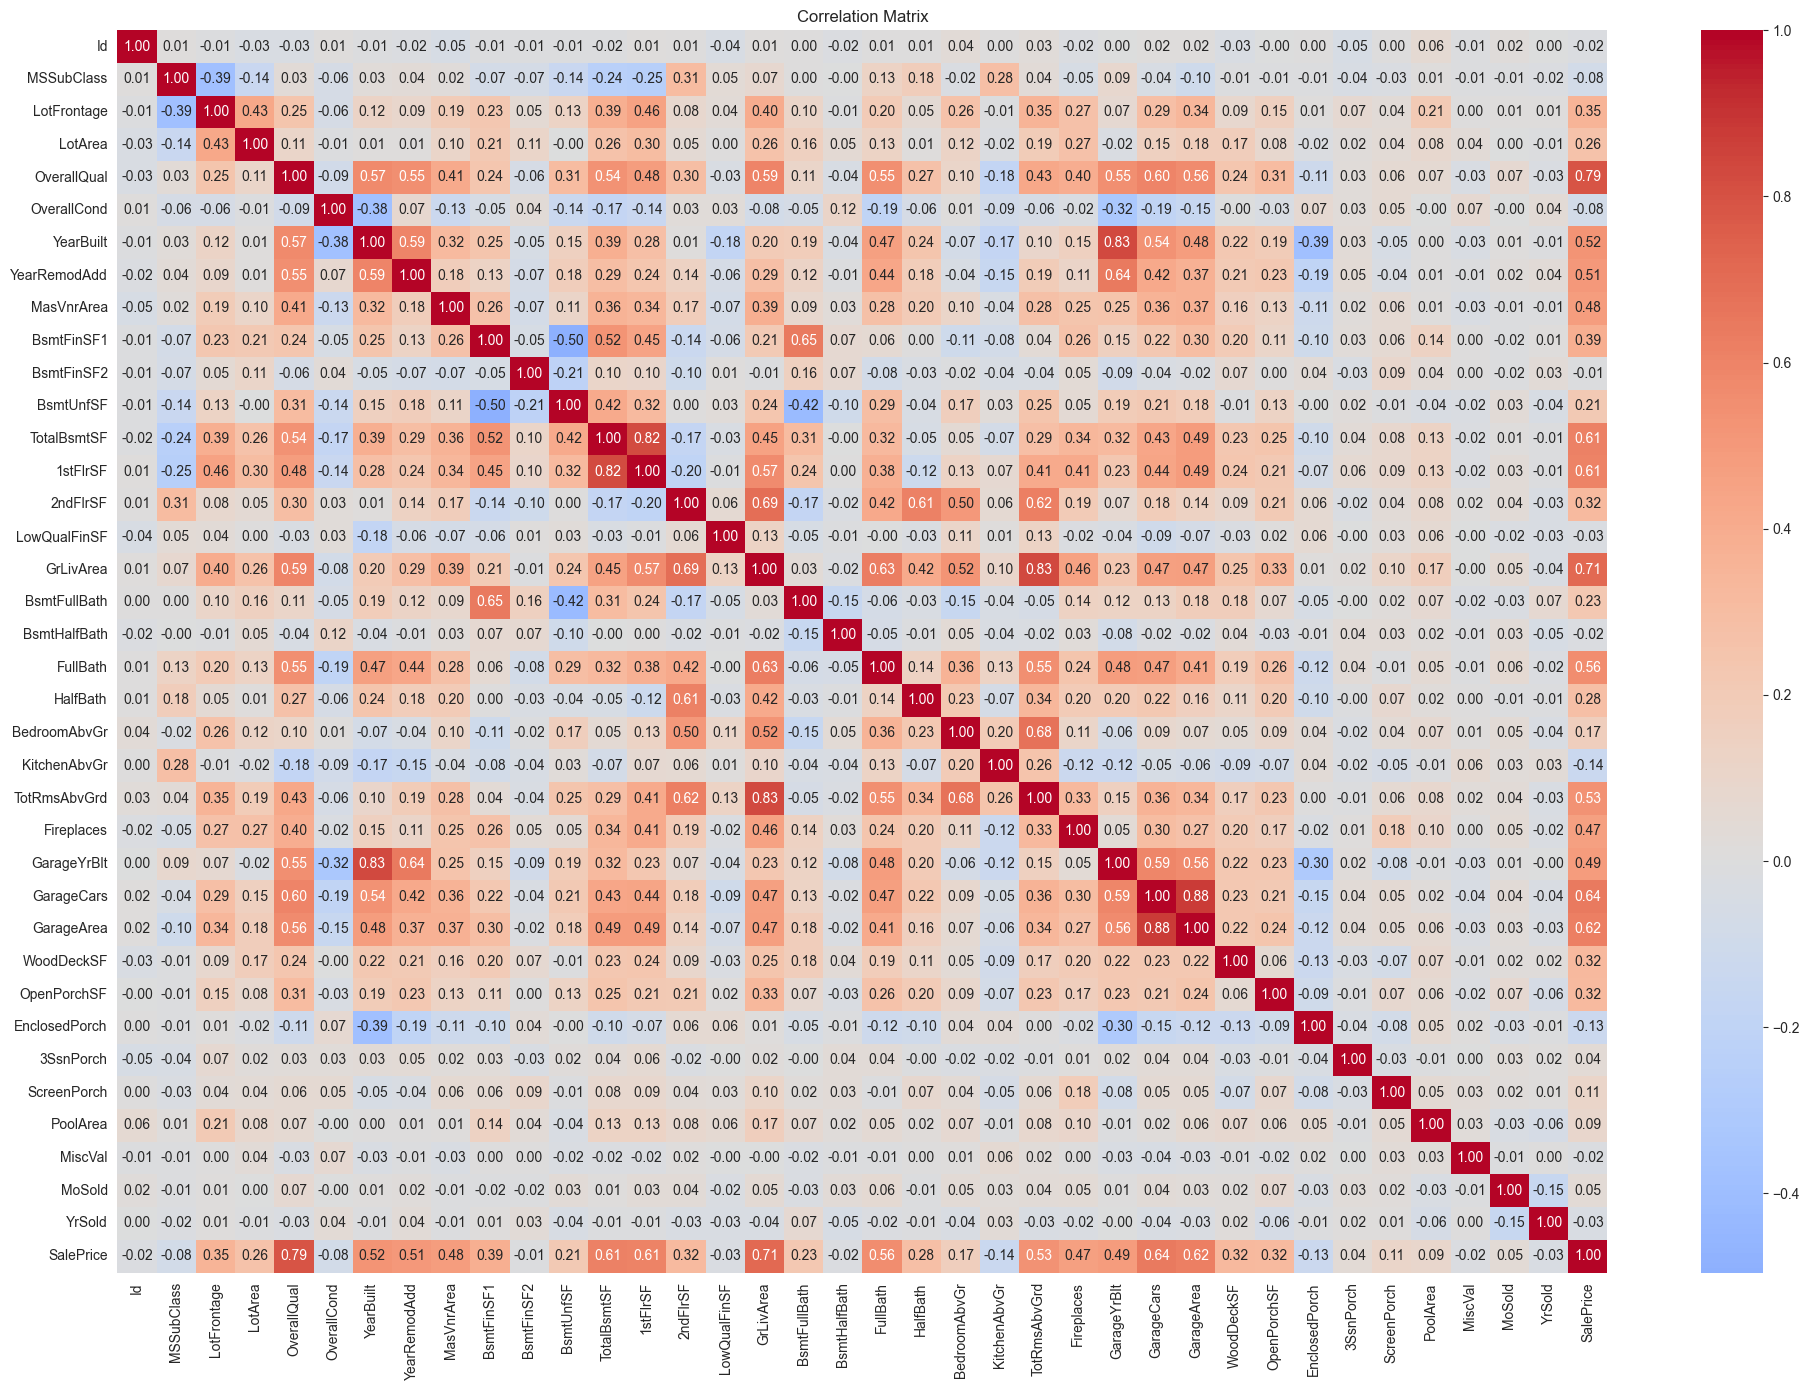

In [15]:
# ============================================================
# 2.6 Correlation heatmap (Ch 3)
# ============================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
# 
plt.figure(figsize=(20, 14))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### YOUR TASK: Answer These 3 EDA Questions

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

   *Your answer:* Sale price is right skewed as most homes are sold in the 100-200k range. A log transformation can be applied to make it more fit for linear regression, however tree-based models handle skew without transformations applied. 

2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?  

   *Your answer:* OverallQual(0.79), GrLivArea(0.71), GarageCars(0.64), and Garage Area (0.62). There is multicollinearity between Garagecars and GarageArea as both measure the garage size. There is also a similiar trend with GrLivArea and TotRmsAbvGrd since larger houses have more rooms overall. 

3. **What is the biggest data quality issue you found, and how will you handle it?**  

   *Your answer:* Missing data in categorical columns. However, these are MNAR, as previsouly explained that means that the home simply lacks the feature, but it is still informative so I will impute them with "none". 

### 2.7 Data Quality Summary

**Data Quality Summary**

My dataset has **N = 1460 ** observations and **M = 80** features.

**Missing data:** 6.6% of cells are missing. The missingness pattern appears to be [MCAR / MAR / MNAR] because MNAR. I will handle missing data by imputing 'none' for categorical columns and 0 for related numeric columns.

**Outliers:** I identified 61 SalePrice and 31 GrLivArea outliers using Tukey Fences / IQR. I will handle them by keeping them, as they represent information for larger homes.

**Target variable:** SalePrice is right-skewed, with most homes landing in the 100-200k range and a long tail of high-value properties. A log transformation may be used for linear models. 

**Key finding from EDA:** OverallQual(r=0.79) and GrLivArea(r=0.71) are the strongest predictors of SalePrice. Neighborhood also shows a large variation in median sale price, showing that it is an important predictor. 

---
## Part 3: Modeling

### 3.1 Train/Test Split

In [16]:
# ============================================================
# 3.1 Train/test split (Ch 6)
# ============================================================


X = df[['GrLivArea', 'OverallQual', 'Neighborhood']]  
y = df['SalePrice']  
# For neighborhood, I need to convert the categorical variable into dummy variables
X = pd.get_dummies(X, columns=['Neighborhood'], drop_first=True) 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')

Train: 1168 samples
Test:  292 samples


### 3.2 Model 1: Baseline

In [18]:
# ============================================================
# 3.2 Model 1 — Baseline
# ============================================================


from sklearn.linear_model import LinearRegression

model_1 = LinearRegression()
model_1.fit(X_train, y_train)
# 
y_pred_1 = model_1.predict(X_test)

print('Model 1: Linear Regression')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_1)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_1):.4f}')
print(f'R2:   {r2_score(y_test, y_pred_1):.4f}')

Model 1: Linear Regression
RMSE: 38547.7417
MAE:  24193.5699
R2:   0.8063


/Users/annabashlakova/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/annabashlakova/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/annabashlakova/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


### 3.3 Model 2: Your Choice

In [19]:
# ============================================================
# 3.3 Model 2 — Your choice
# ============================================================
from sklearn.ensemble import RandomForestRegressor  
# 
model_2 = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
model_2.fit(X_train, y_train)
# 
y_pred_2 = model_2.predict(X_test)

print('Model 2: Random Forest')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_2)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_2):.4f}')
print(f'R2:   {r2_score(y_test, y_pred_2):.4f}')

Model 2: Random Forest
RMSE: 32864.3820
MAE:  22059.1038
R2:   0.8592


### 3.4 Cross-Validation Comparison

In [20]:
# ============================================================
# 3.4 Cross-validation (Ch 15)
# ============================================================
scoring = 'neg_mean_squared_error' 
cv_1 = cross_val_score(model_1, X_train, y_train, cv=5, scoring=scoring)
cv_2 = cross_val_score(model_2, X_train, y_train, cv=5, scoring=scoring)
# Had to convert to RMSE 
rmse_1 = np.sqrt(-cv_1)
rmse_2 = np.sqrt(-cv_2)

print(f'Model 1 CV RMSE: {rmse_1.mean():.4f} +/- {rmse_1.std():.4f}')
print(f'Model 2 CV RMSE: {rmse_2.mean():.4f} +/- {rmse_2.std():.4f}')
# 
# # Comparison table
comparison = pd.DataFrame({
     'Model': ['Model 1 (Baseline)', 'Model 2 (Your Choice)'],
     f'CV {scoring} (mean)': [cv_1.mean(), cv_2.mean()],
     f'CV {scoring} (std)': [cv_1.std(), cv_2.std()],
 })
comparison

/Users/annabashlakova/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/annabashlakova/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/annabashlakova/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/annabashlakova/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/annabashlakova/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/annabashlakova/Library/Python/3.9/lib/python/site-p

Model 1 CV RMSE: 37379.6168 +/- 4391.6370
Model 2 CV RMSE: 36671.8935 +/- 3430.9369


,Model,CV neg_mean_squared_error (mean),CV neg_mean_squared_error (std)
0,Model 1 (Baseline),-1.416522e+09,3.352513e+08
1,Model 2 (Your Choice),-1.356599e+09,2.476030e+08


---
## Part 4: Feature Importance + Visualization

### 4.1 Feature Importance

In [ ]:
# ============================================================
# 4.1 Feature importance (Ch 19)
# ============================================================

# # For tree-based models:
# importances = pd.Series(
#     model_2.feature_importances_, index=X.columns
# ).sort_values(ascending=True)
# 
# fig, ax = plt.subplots(figsize=(8, 6))
# importances.plot(kind='barh', ax=ax, color='steelblue')
# ax.set_xlabel('Feature Importance (Gini)')
# ax.set_title('Feature Importance — Predictive, NOT Causal')
# 
# # CRITICAL: Add the caveat banner
# ax.text(
#     0.98, 0.02,
#     'Predictive importance only.\nDoes not imply causal effect.',
#     transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
#     style='italic', color='#c0392b',
#     bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
# )
# 
# plt.tight_layout()
# plt.show()

### 4.2 Key Visualization for Your Report

In [ ]:
# ============================================================
# 4.2 Your key visualization
# ============================================================
# This is the ONE chart you would put on the first page of your report.
# It should communicate your main finding clearly.
#
# Examples:
#   - Actual vs. predicted scatter (regression)
#   - Confusion matrix heatmap (classification)
#   - ROC curve comparison (classification)
#   - Partial dependence plot for top feature

# YOUR CODE HERE

---
## Part 5: Recommendation

Use the SCR (Situation-Complication-Resolution) structure from Chapter 26.

**Situation:** ___
(What is the context? Who is the stakeholder? What decision do they face?)

**Complication:** ___
(What makes this decision hard? What uncertainty exists? What did your analysis reveal?)

**Resolution:** ___
(What do you recommend? Based on what evidence? With what confidence?)

**Uncertainty Statement:** Based on our cross-validation results (metric = ___ +/- ___), we estimate that ___. The primary limitation is ___. We recommend ___ with the caveat that ___.

---
## Part 6: Streamlit Export Guide

### 6.1 Creating app.py

Your Streamlit app should contain:
1. **Title and description** — `st.title()`, `st.markdown()`
2. **Input controls** — `st.slider()`, `st.selectbox()`, `st.number_input()`
3. **Model prediction** — load your trained model, generate predictions from user inputs
4. **Visualization** — at least one chart that updates with user inputs
5. **Uncertainty** — display confidence/prediction intervals alongside point estimates

### 6.2 Minimal app.py Template

```python
import streamlit as st
import pandas as pd
import numpy as np
import joblib  # to load saved model

st.title('Your Project Title')
st.markdown('Brief description of what this app predicts.')

# Sidebar controls
feature_1 = st.sidebar.slider('Feature 1', min_value=0.0, max_value=100.0, value=50.0)
feature_2 = st.sidebar.selectbox('Feature 2', ['Option A', 'Option B', 'Option C'])

# Load model (save with joblib.dump(model, 'model.pkl') in your notebook)
model = joblib.load('model.pkl')

# Predict
input_data = pd.DataFrame({'feature_1': [feature_1], 'feature_2': [feature_2]})
prediction = model.predict(input_data)[0]

st.metric('Prediction', f'{prediction:.2f}')
```

### 6.3 requirements.txt Template

```
streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0
```

### 6.4 Deployment Steps

1. Save your model: `joblib.dump(model_2, 'model.pkl')`
2. Test locally: `streamlit run app.py`
3. Push to GitHub: `app.py`, `model.pkl`, `requirements.txt`
4. Go to [streamlit.io/cloud](https://streamlit.io/cloud) and deploy
5. Submit the permanent URL on Canvas

---
## Part 7: AI Methodology Appendix

Document at least **3 AI interactions** using the P.R.I.M.E. framework. Copy and fill in the template below for each interaction.

---

### AI Interaction 1

**Prep:** What did you need? What context did you have before prompting?
> ___

**Request:** What exact prompt did you write?
> ___

**Iterate:** What did the AI return? What did you change or refine?
> ___

**Mechanism Check:** How did you verify the output was correct?
> ___

**Evaluate:** What human judgment did you apply? What did you accept/reject and why?
> ___

---

### AI Interaction 2

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___

---

### AI Interaction 3

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___